# Starlib Rates

This notebook illustrates several integrations of a CNO network each with a unique sampling of Starlib rates and compares it against a network intergration carried out with Reaclib rates.

In [1]:
import pynucastro as pyna

First, let's integrate a CNO network with Starlib rates at median values.

In [2]:
sl = pyna.StarLibLibrary()
nuclei =  ["p", "he4", "c12", "c13", "n13",
           "n14", "n15", "o14", "o15" ]

In [3]:
lib = sl.linking_nuclei(nuclei)
net = pyna.PythonNetwork(libraries=lib)

Set composition roughly to that of the sun's core.

In [4]:
rho = 150
T = 1.5e7

comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("p")] = 0.7
comp.X[pyna.Nucleus("he4")] = 0.28
comp.X[pyna.Nucleus("c12")] = 0.02

Y0 = comp.get_molar_array()

Then, we are ready to integrate.

In [5]:
tmax = 1.e20
sol_median = net.integrate_network(tmax, rho, T, Y0, atol=1.e-8)

A `PythonNetwork` is a subclass of `RateCollection`, so we can repeatedly resample the existing network, integrate, and store each solution for visualization.

In [6]:
import numpy as np
np.random.seed(6789)

In [7]:
nsamples=20
sampled_sols = []
for seed in np.random.randint(0, 10000, size=nsamples):
    net.resample(seed=seed)
    sol = net.integrate_network(tmax, rho, T, Y0, atol=1.e-8)
    sampled_sols.append(sol)

As mentioned, we integrate the same network with Reaclib rates for comparison.

In [8]:
rl = pyna.ReacLibLibrary()
lib = rl.linking_nuclei(nuclei)
rnet = pyna.PythonNetwork(libraries=lib)
sol_reaclib = net.integrate_network(tmax, rho, T, Y0, atol=1.e-8)

# Visualization of Results

The following code evaluates solutions with sampled rates at consistent time stamps, finds the minimum and maximum value for each relevant mass fraction at each time stamp across solutions, and illustrates the spread in mass fraction given the rate sampling.

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [10]:
ts = np.logspace(1, 20, num=500)

In [11]:
X_min = np.zeros((len(sol.unique_nuclei), len(ts)))
X_max = np.zeros((len(sol.unique_nuclei), len(ts)))

In [12]:
for i, t in enumerate(ts):
    _Xmin = np.ones(len(sol.unique_nuclei))
    _Xmax = np.zeros(len(sol.unique_nuclei))
    for sol in sampled_sols:
        X = sol.X_at(t)
        _Xmin[:] = np.minimum(_Xmin, X)
        _Xmax[:] = np.maximum(_Xmax, X)
    X_min[:, i] = _Xmin[:]
    X_max[:, i] = _Xmax[:]

The plots are made such that the solid line depicts the solution with Starlib rates at median values, the darker dotted line depicts the solution with Reaclb rates and the shading depicts the uncertainty in the Starlib solution determined via the solutions with sampled Starlib rates.

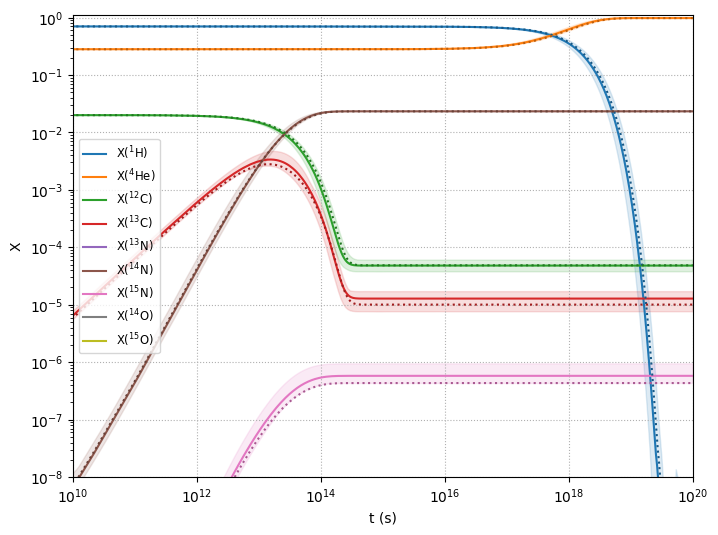

In [14]:
#Provides a darker shade for reaclib
def darken(color):
    rgb = mcolors.to_rgb(color)
    return tuple(c * 0.75 for c in rgb)


fig, ax = plt.subplots()

for i, nuc in enumerate(sol_median.unique_nuclei):
    ax.fill_between(ts, X_min[i, :], X_max[i, :], color=f"C{i}", alpha=0.15)

for i, nuc in enumerate(sol_median.unique_nuclei):
    label = f"X$({nuc.pretty})$"
    ax.loglog(sol_median.t, sol_median.X[i, :], label=label, color=f"C{i}")

for i, nuc in enumerate(sol_reaclib.unique_nuclei):
    ax.loglog(sol_reaclib.t, sol_reaclib.X[i, :], color=darken(f"C{i}"), linestyle=":")

ax.set_xlim(1.e10, 1.e20)
ax.set_ylim(1.e-8, 1.1)

ax.legend(fontsize="small")
ax.grid(ls=":")
ax.set_xlabel("t (s)")
ax.set_ylabel("X")
fig.set_size_inches((8, 6))